In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
letters = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
# plt.rcParams['font.size']      = 18
plt.rcParams['font.weight']       = 'bold'
plt.rcParams['axes.labelweight']  = 'bold'
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.grid']      = True
plt.rcParams['axes.xmargin']   = 0
plt.rcParams['grid.linestyle'] = ':'

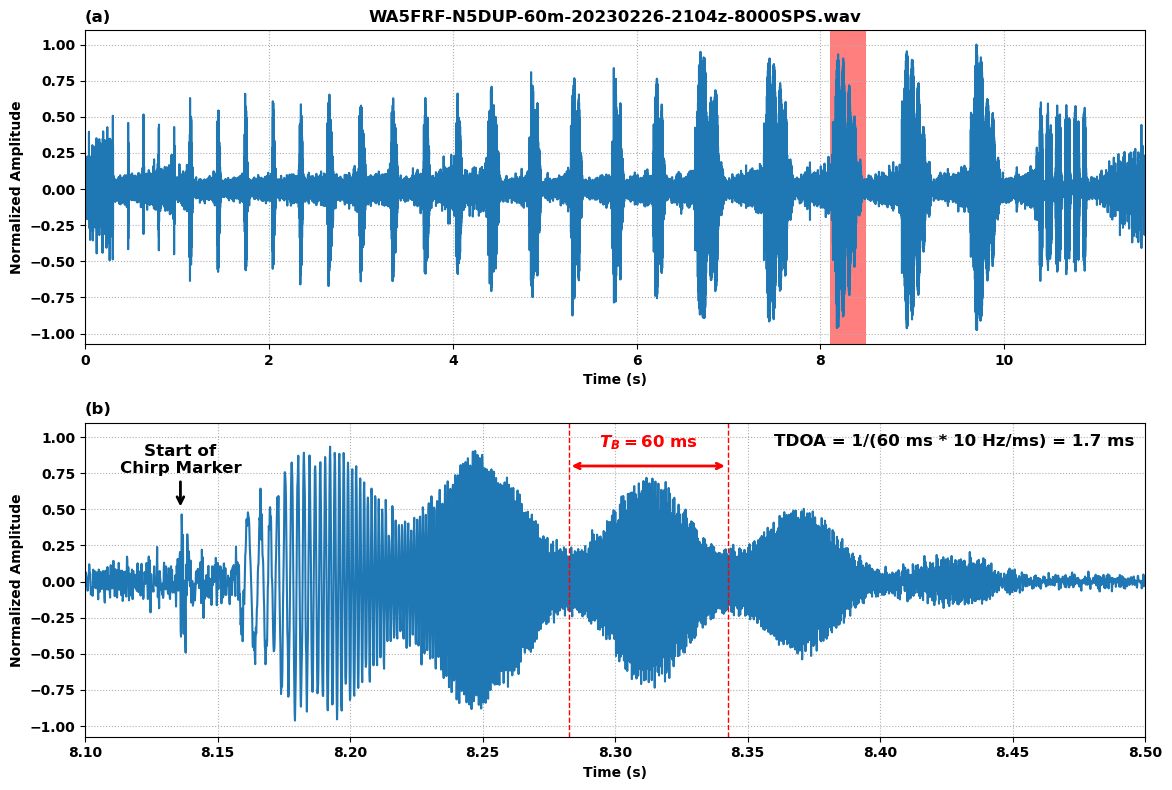

In [3]:
fname = 'WA5FRF-N5DUP-60m-20230226-2104z-8000SPS.wav'
file_path = os.path.join('wav',fname)

xlim = (8.1, 8.5)

sample_rate, data = wavfile.read(file_path)
data = data / np.max(np.abs(data))  # Normalize the data to -1 to 1

duration = len(data) / sample_rate
time = np.linspace(0, duration, num=len(data))

nrows = 2
fig = plt.figure(figsize=(12, 4*nrows))
pinx = 0

########################################
pinx += 1
ax = fig.add_subplot(nrows, 1, pinx)
ax.plot(time, data)
ax.set_title(f'({letters[pinx-1]})',loc='left')
ax.set_title(fname)
ax.set_ylabel("Normalized Amplitude")
ax.axvspan(8.1, 8.5, facecolor='red', alpha=0.5, label='Signal of Interest')
ax.set_xlabel("Time (s)")

########################################
pinx += 1
ax = fig.add_subplot(nrows, 1, pinx)
ax.plot(time, data)
ax.set_title(f'({letters[pinx-1]})',loc='left')
ax.set_ylabel("Normalized Amplitude")
ax.set_xlim(xlim)
ax.set_xlabel("Time (s)")

xmark = 8.136
ax.annotate(
    'Start of\nChirp Marker',
    xy=(xmark, 0.5),           # Point to annotate (x, y in data coordinates)
    xytext=(xmark, 0.75),     # Position of the text
    arrowprops=dict(facecolor='black', arrowstyle='->',linewidth=2),
    fontsize=12,
    color='black',
    ha='center'
)

beat_color = 'red'
xx_0 = 8.2825
xx_1 = 8.3425
T_B  = xx_1 - xx_0
ax.axvline(xx_0, color=beat_color, linestyle='--', linewidth=1)
ax.axvline(xx_1, color=beat_color, linestyle='--', linewidth=1)

yy_0 = 0.80
ax.annotate(
    '',  # No text
    xy=(xx_1, yy_0),    # End of arrow (x, y)
    xytext=(xx_0, yy_0),# Start of arrow (x, y)
    arrowprops=dict(
        arrowstyle='<->',
        color=beat_color,
        linewidth=2
    ),
    annotation_clip=False
)
ax.text(
    (xx_0 + xx_1) / 2, yy_0+0.1,  # Position above the arrow
    f'$T_B = {T_B*1e3:.0f}$ ms',
    ha='center', va='bottom', color=beat_color, fontsize=12
)

txt = 'TDOA = 1/(60 ms * 10 Hz/ms) = 1.7 ms'
ax.text(0.65,0.925,txt,transform=ax.transAxes,fontsize=12)

fig.tight_layout()
fig.show()
fig.savefig('fig_05.jpg',dpi=300,bbox_inches='tight')